In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
import cv2

In [2]:
df=pd.read_csv(r'../data/processed/FinalData.csv')

In [3]:
df

,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression
0,1,1_IM-0001-4001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,NaN,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,1,1_IM-0001-3001.dcm.png,Lateral,normal,normal,Xray Chest PA and Lateral,Positive TB test,NaN,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,2,2_IM-0652-1001.dcm.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,NaN,Borderline cardiomegaly. Midline sternotomy . ...,No acute pulmonary findings.
3,2,2_IM-0652-2001.dcm.png,Lateral,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,NaN,Borderline cardiomegaly. Midline sternotomy . ...,No acute pulmonary findings.
4,3,3_IM-1384-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",[RecursionError],"No displaced rib fractures, pneumothorax, or p...","No displaced rib fractures, pneumothorax, or p..."
...,...,...,...,...,...,...,...,...,...,...
7290,3997,3997_IM-2048-1002.dcm.png,Lateral,Opacity/lung/upper lobe/right/round/small;Gran...,Opacity;Granuloma,PA and lateral views of the chest.,XXXX-year-old male with positive PPD.,Noneavailable.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB."
7291,3998,3998_IM-2048-1001.dcm.png,Frontal,normal,normal,"PA and lateral chest XXXX, XXXX XXXX comparis...",tuberculosis positive PPD,[RecursionError],Heart size is normal and the lungs are clear.,Heart size is normal and the lungs are clear.
7292,3998,3998_IM-2048-1002.dcm.png,Lateral,normal,normal,"PA and lateral chest XXXX, XXXX XXXX comparis...",tuberculosis positive PPD,[RecursionError],Heart size is normal and the lungs are clear.,Heart size is normal and the lungs are clear.
7293,3999,3999_IM-2049-1001.dcm.png,Frontal,normal,normal,"CHEST PA and LATERAL: on XXXX, XXXX.",This is a XXXX-year-old female patient with sh...,"Chest x-None, None, None.",The cardiac silhouette is normal in size and c...,The cardiac silhouette is normal in size and c...


In [4]:
sample_image="../data/raw/images/images_normalized/1000_IM-0003-1001.dcm.png"
img=cv2.imread(sample_image,cv2.IMREAD_GRAYSCALE)
img_res=cv2.resize(img,(224,224))
cv2.imshow("X-Ray Sample", img_res)  # ✅ window name + array
cv2.waitKey(0)                   # 0 = استنى لحد ما تضغط أي زر
cv2.destroyAllWindows()

In [5]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# ✅ الـ base path الصح
base_path = "../data/raw/images/images_normalized/"

# ✅ أضف الـ base path للـ filenames
image_paths = df["filename"].apply(lambda x: os.path.join(base_path, x)).values
labels      = df["projection"].values

# ✅ تحقق سريع
print("Sample path:", image_paths[0])
print("Exists:", os.path.exists(image_paths[0]))


Sample path: ../data/raw/images/images_normalized/1_IM-0001-4001.dcm.png
Exists: True


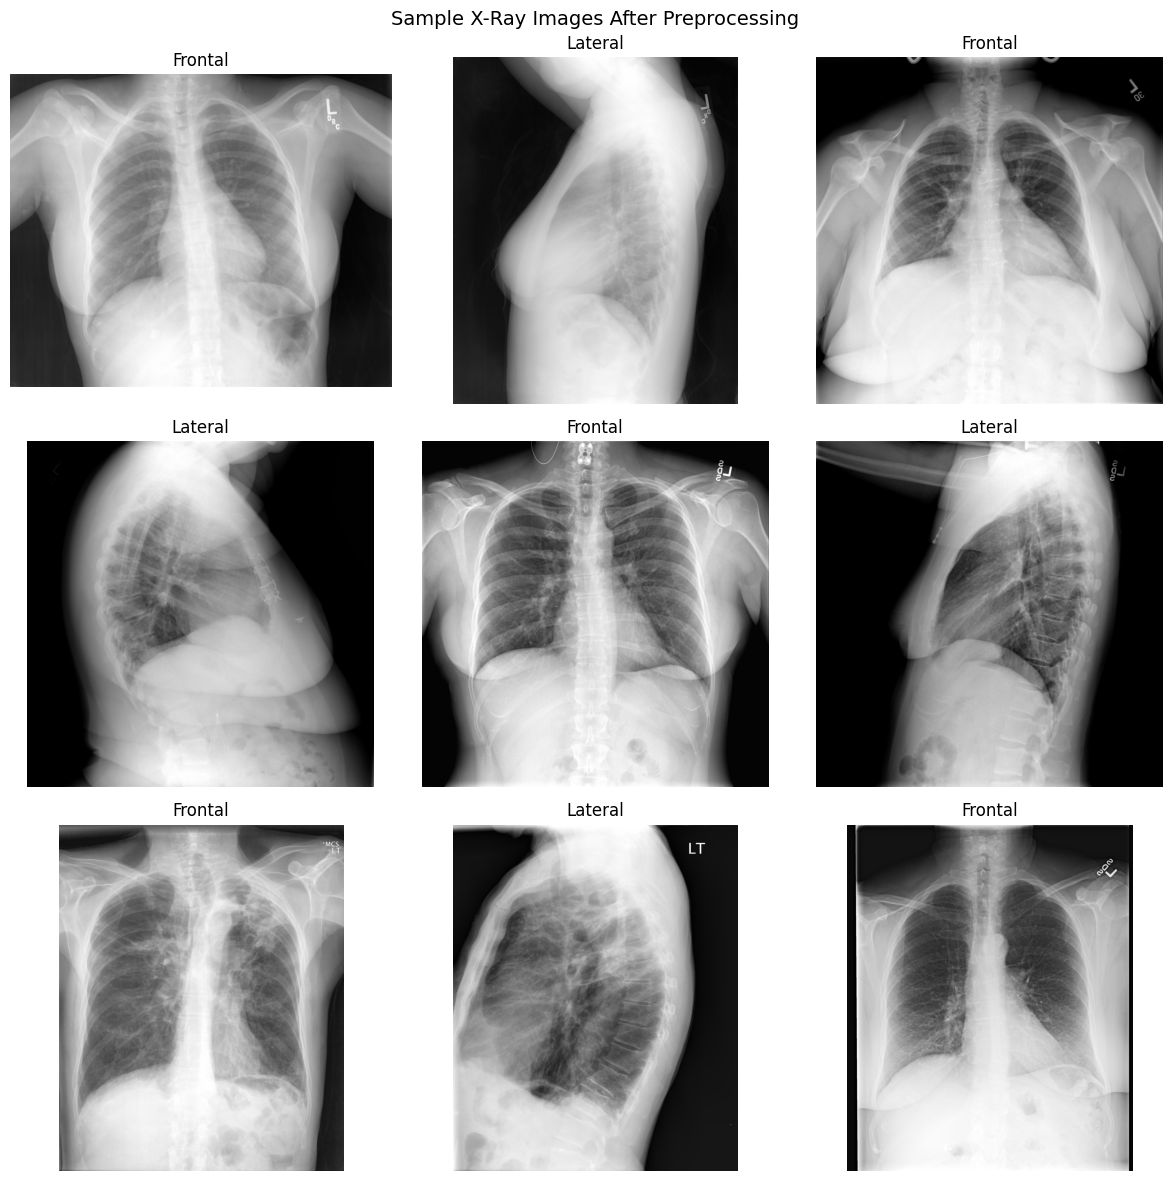

In [6]:
# ✅ عرض أول 9 صور

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img=cv2.imread(image_paths[i])
    plt.imshow(img)
    plt.title(str(labels[i]))
    plt.axis("off")

plt.suptitle("Sample X-Ray Images After Preprocessing", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0
    return img

def enhance_xray(image):
    # ✅ تأكد إن الصورة array وليست scalar
    image = np.array(image)
    
    img = (image[:, :, 0] * 255).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)

    kernel = np.array([[ 0, -0.5,  0],
                    [-0.5,  3, -0.5],
                    [ 0, -0.5,  0]])
    img = cv2.filter2D(img, ddepth=-1, kernel=kernel*0.9)

    img = np.clip(img, 0, 255) / 255.0
    return img[:, :, np.newaxis].astype(np.float32)  # ✅ تأكد النوع float32

def preprocess(path, label):
    image = load_image(path)
    image = tf.py_function(enhance_xray, [image], tf.float32)
    image.set_shape([224, 224, 1])
    return image, label


dataset = (tf.data.Dataset.from_tensor_slices((image_paths, labels))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)



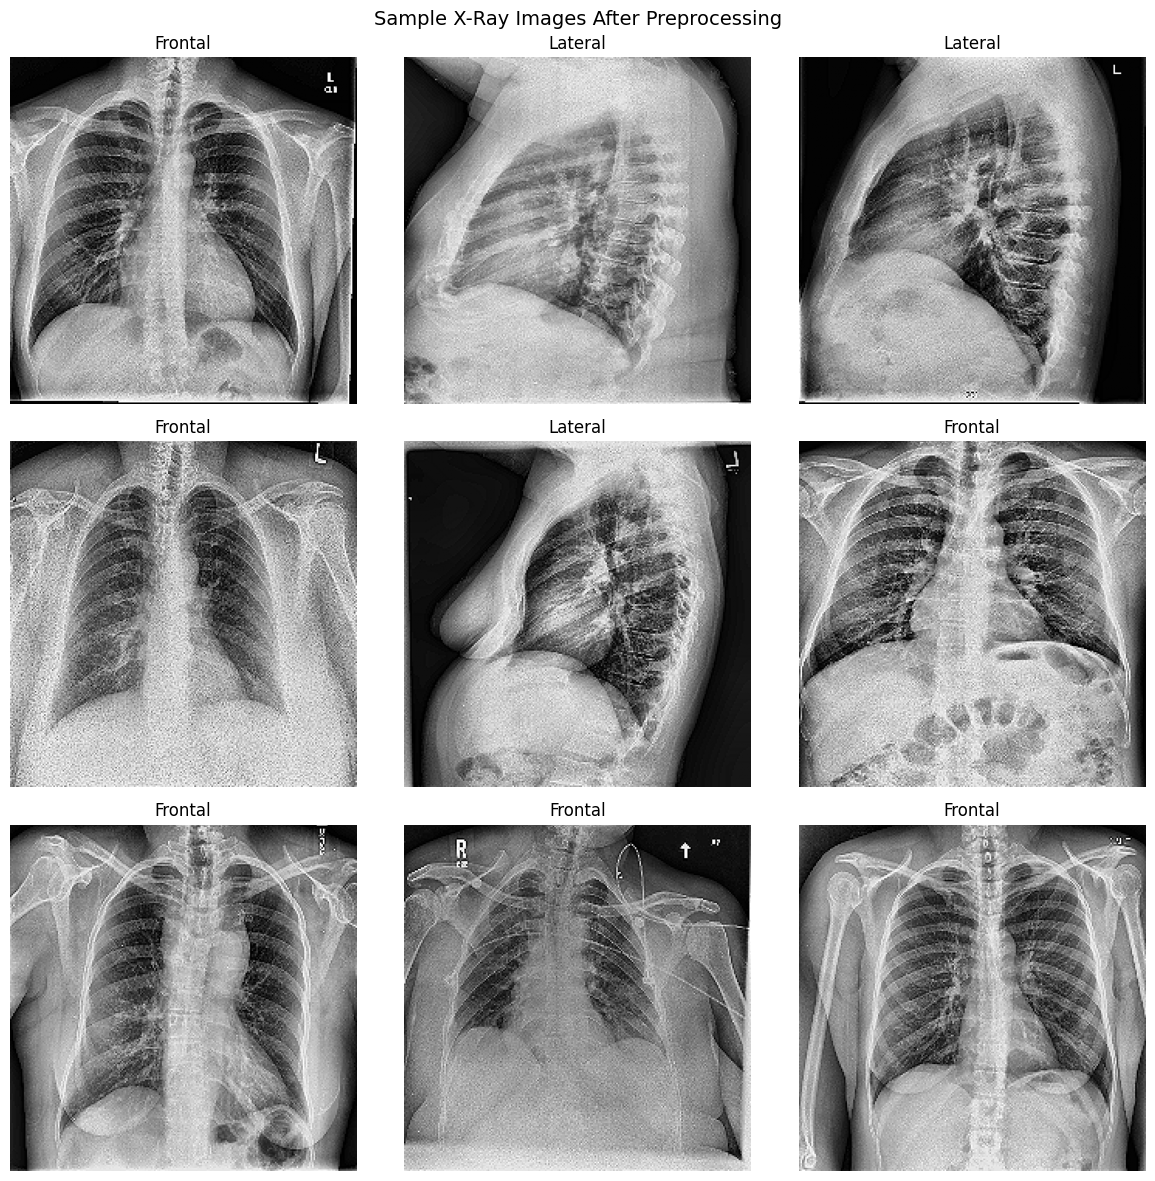

In [22]:
# ✅ عرض أول 9 صور
images, labels_batch = next(iter(dataset))

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy()[:, :, 0], cmap="gray")
    plt.title(labels_batch[i].numpy().decode("utf-8"))
    plt.axis("off")

plt.suptitle("Sample X-Ray Images After Preprocessing", fontsize=14)
plt.tight_layout()
plt.show()